 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Libraries and Import All Required Packages

In [ ]:
# ── INSTALL ──────────────────────────────────────────────────────────
!pip install wordcloud gensim gradio nltk contractions -q

# ── IMPORTS ──────────────────────────────────────────────────────────
import re, os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import gensim.downloader as api

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
All libraries imported successfully


 Load the Dataset and Explore Its Structure

In [ ]:

# ── STEP 1: Load the dataset ─────────────────────────────────────
df= pd.read_csv("/content/drive/MyDrive/dataset/truevsfakenews.csv")

print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nValue counts per column:")
for col in df.columns:
    print(f"\n--- [{col}] ---")
    print(df[col].value_counts())

Shape          : (20000, 2)
Columns        : ['text', 'label']

Data Types:
text     object
label    object
dtype: object

First 5 rows:
                                                text label
0  WASHINGTON (Reuters) - The Republican and Demo...  true
1  Women should get as far away from Oklahoma as ...  fake
2  Another huge crowd of Americans tuned in last ...  fake
3  Donald Trump is desperate to stop the investig...  fake
4  (Reuters) - Planned Parenthood, the U.S. medic...  true

Missing values:
text     0
label    0
dtype: int64

Value counts per column:

--- [text] ---
text
(Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nucl

Detect Label Column, Encode Labels, and Prepare the Content Column

In [ ]:
label_col = None
for col in df.columns:
    unique_vals = df[col].astype(str).str.strip().str.lower().unique()
    if set(unique_vals).issubset({'true', 'fake', 'real', 'false', '0', '1'}):
        label_col = col
        print(f"Label column detected: '{label_col}'")
        print(f"   Unique values: {unique_vals}")
        break

if label_col is None:
    label_col = 'label'
    print(f"Could not auto-detect. Using default: '{label_col}'")

df[label_col] = df[label_col].astype(str).str.strip().str.lower()

label_map = {'true': 1, 'real': 1, '1': 1,
             'fake': 0, 'false': 0, '0': 0}
df['label'] = df[label_col].map(label_map)

print(f"\nLabel distribution after encoding:")
print(df['label'].value_counts())
print(f"NaN labels: {df['label'].isnull().sum()}")

text_col = None
for col in df.columns:
    if col == label_col:
        continue
    if df[col].dtype == object:
        avg_len = df[col].astype(str).apply(len).mean()
        if avg_len > 30:
            text_col = col
            print(f"\nText column detected: '{text_col}'  (avg length: {avg_len:.0f} chars)")
            break

if 'title' in df.columns and 'text' in df.columns:
    df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
    print("\nCombined 'title' + 'text' into 'content'")
elif text_col:
    df['content'] = df[text_col].fillna('')
    print(f"\nUsing '{text_col}' as content column")

df = df.dropna(subset=['label', 'content'])
df = df[df['content'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f"\nDataset ready!")
print(f"   Total rows  : {len(df)}")
print(f"   Label counts:\n{df['label'].value_counts()}")

Label column detected: 'label'
   Unique values: ['true' 'fake']

Label distribution after encoding:
label
1    10000
0    10000
Name: count, dtype: int64
NaN labels: 0

Text column detected: 'text'  (avg length: 2598 chars)

Using 'text' as content column

Dataset ready!
   Total rows  : 19999
   Label counts:
label
0    10000
1     9999
Name: count, dtype: int64


Visualise Class Distribution (Bar Chart and Pie Chart)

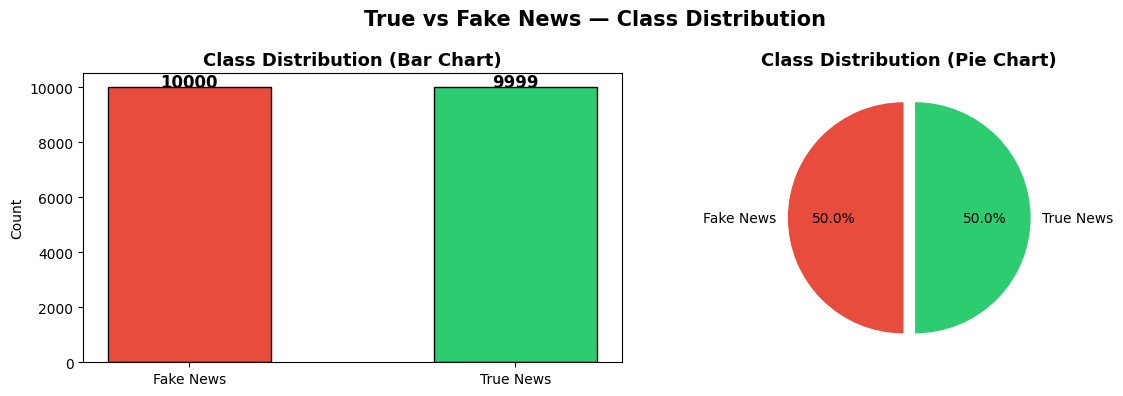

Class distribution plotted!


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

label_names   = {0: 'Fake News', 1: 'True News'}
counts        = df['label'].value_counts().sort_index()
labels_mapped = [label_names[int(l)] for l in counts.index]

bars = ax[0].bar(labels_mapped, counts.values,
                 color=['#e74c3c', '#2ecc71'],
                 edgecolor='black', width=0.5)
ax[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

ax[1].pie(counts.values,
          labels=labels_mapped,
          autopct='%1.1f%%',
          colors=['#e74c3c', '#2ecc71'],
          startangle=90,
          explode=(0.05, 0.05))
ax[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('True vs Fake News — Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution plotted!")

Define the Text Cleaning Function

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Keep negation words so meaning is preserved
keep_words = {'not', 'no', 'nor', 'never', 'neither', 'but', 'against'}
stop_words -= keep_words

def clean_text(text):
    """
    Full text cleaning pipeline:
    1.  Lowercase all text
    2.  Expand contractions  (don't -> do not)
    3.  Remove URLs
    4.  Remove @mentions
    5.  Remove hashtags (word and symbol)
    6.  Remove numbers
    7.  Remove punctuation / special characters
    8.  Remove extra whitespace
    9.  Remove stopwords
    10. Lemmatize words to their base form
    """
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'_', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(tokens)

sample = "BREAKING: Trump doesn't support @user! Visit http://fake.com #Politics 2024"
print("Before:", sample)
print("After :", clean_text(sample))

Before: BREAKING: Trump doesn't support @user! Visit http://fake.com #Politics 2024
After : breaking trump not support visit


Apply Text Cleaning to the Entire Dataset

In [ ]:
print("Cleaning text... please wait (1-2 minutes)")

df['cleaned_text'] = df['content'].apply(clean_text)

df['len_before'] = df['content'].apply(lambda x: len(str(x).split()))
df['len_after']  = df['cleaned_text'].apply(lambda x: len(str(x).split()))

df = df[df['cleaned_text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text'])
df.reset_index(drop=True, inplace=True)

print(f"Cleaning complete!  Remaining rows: {len(df)}")
print(f"\nAverage word count BEFORE cleaning : {df['len_before'].mean():.0f}")
print(f"Average word count AFTER  cleaning : {df['len_after'].mean():.0f}")
reduction = (df['len_before'].mean() - df['len_after'].mean()) / df['len_before'].mean() * 100
print(f"Reduction                          : {reduction:.1f}%")
print(f"\nLabel counts after cleaning:")
print(df['label'].value_counts())

print("\n=== Sample Before vs After ===")
for i in range(3):
    print(f"\n[{i+1}] Original : {df['content'][i][:100]}...")
    print(f"    Cleaned  : {df['cleaned_text'][i][:100]}...")

Cleaning text... please wait (1-2 minutes)
Cleaning complete!  Remaining rows: 19998

Average word count BEFORE cleaning : 426
Average word count AFTER  cleaning : 241
Reduction                          : 43.5%

Label counts after cleaning:
label
1    9999
0    9999
Name: count, dtype: int64

=== Sample Before vs After ===

[1] Original : WASHINGTON (Reuters) - The Republican and Democratic leaders of the U.S. Senate Foreign Relations Co...
    Cleaned  : washington reuters republican democratic leader yous senate foreign relation committee blasted yous ...

[2] Original : Women should get as far away from Oklahoma as soon as possible because Christian Sharia law is about...
    Cleaned  : woman get far away oklahoma soon possible christian sharia law make life living hellif oklahoma stat...

[3] Original : Another huge crowd of Americans tuned in last week as the Republicans held their latest fear-fest, a...
    Cleaned  : another huge crowd american tuned last week republican held la

Generate Word Cloud for All Articles

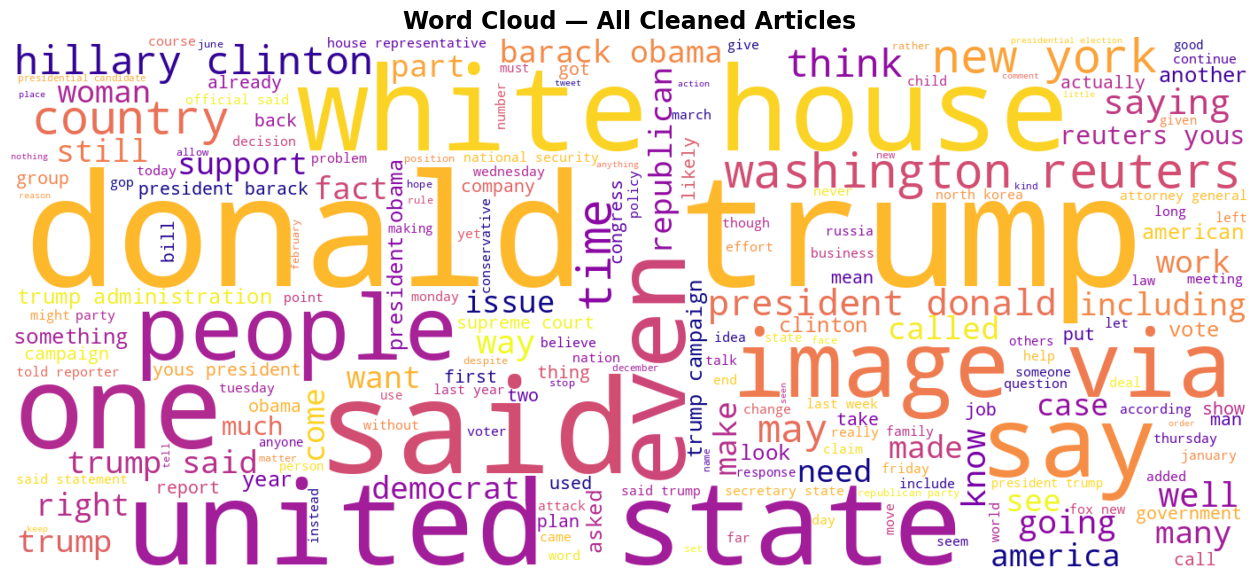

Word cloud generated!


In [ ]:
all_words = ' '.join(df['cleaned_text'].values)

wc = WordCloud(
    width=1400, height=600,
    background_color='white',
    colormap='plasma',
    max_words=200
).generate(all_words)

plt.figure(figsize=(16, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Cleaned Articles', fontsize=17, fontweight='bold')
plt.savefig('wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word cloud generated!")

Generate Word Clouds Separately for True and Fake News

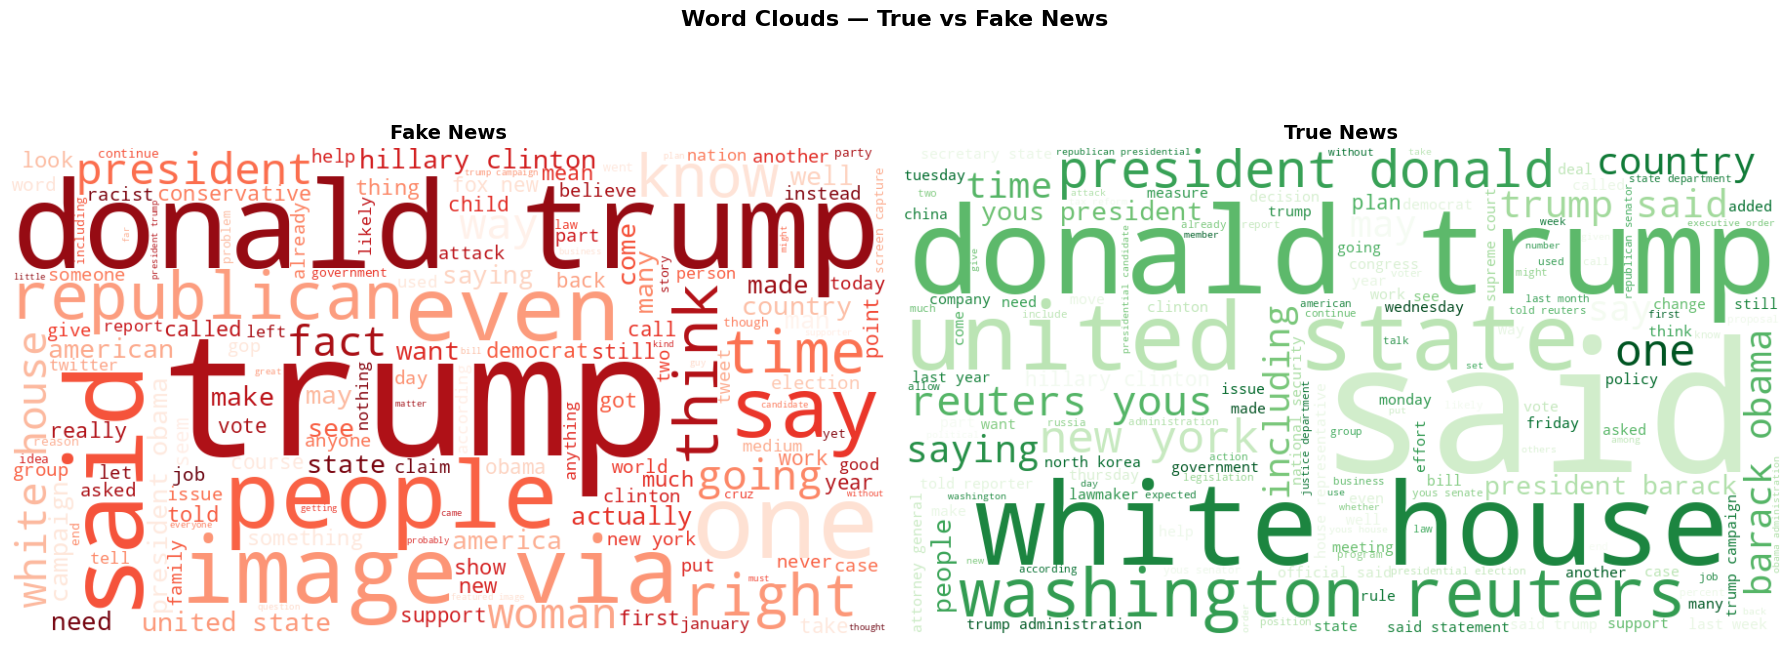

Word clouds by class generated!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Word Clouds — True vs Fake News', fontsize=16, fontweight='bold', y=1.02)

for idx, (label_val, colormap, title) in enumerate([
    (0, 'Reds',  'Fake News'),
    (1, 'Greens', 'True News')
]):
    subset = df[df['label'] == label_val]['cleaned_text'].values
    words  = ' '.join(subset)
    wc = WordCloud(
        width=900, height=500,
        background_color='white',
        colormap=colormap,
        max_words=150
    ).generate(words)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word clouds by class generated!")

Plot Top 20 Most Frequent Words for True and Fake News

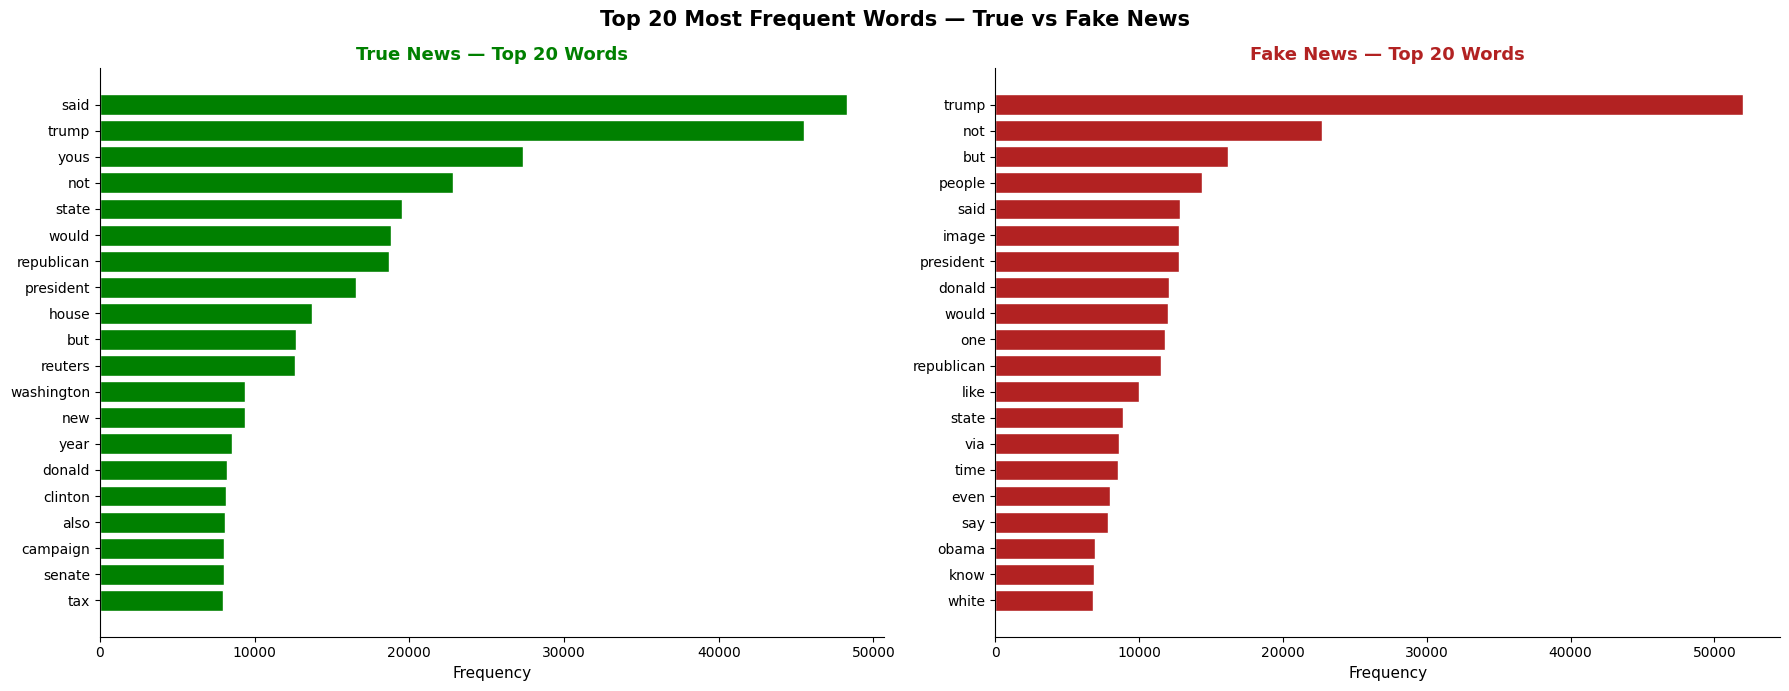

Top 20 words plotted!


In [ ]:
def get_top_words(dataframe, label_val, n=20):
    text = ' '.join(dataframe[dataframe['label'] == label_val]['cleaned_text'].values)
    return Counter(text.split()).most_common(n)

true_top = get_top_words(df, 1)
fake_top = get_top_words(df, 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 20 Most Frequent Words — True vs Fake News', fontsize=15, fontweight='bold')

for ax, top_words, title, color in zip(
    axes,
    [true_top, fake_top],
    ['True News — Top 20 Words', 'Fake News — Top 20 Words'],
    ['green', 'firebrick']
):
    words_f, counts_f = zip(*top_words)
    ax.barh(words_f[::-1], counts_f[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Frequency', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('top20_words_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 20 words plotted!")

Analyse Text Length Distribution and Select MAX_LEN

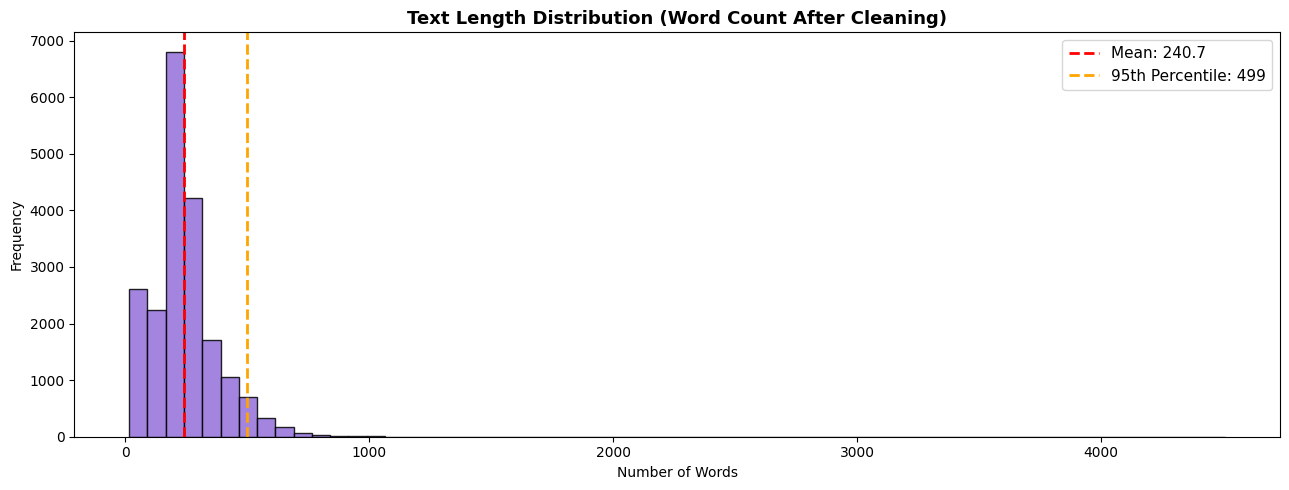

Mean length   : 240.7 words
Median length : 222.0 words
95th pct      : 499 words  <- will be used as MAX_LEN
Max length    : 4508 words


In [ ]:
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

mean_len   = df['text_length'].mean()
median_len = df['text_length'].median()
pct_95     = df['text_length'].quantile(0.95)

plt.figure(figsize=(13, 5))
plt.hist(df['text_length'], bins=60, color='mediumpurple', edgecolor='black', alpha=0.85)
plt.axvline(mean_len, color='red',    linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
plt.axvline(pct_95,   color='orange', linestyle='--', linewidth=2, label=f'95th Percentile: {pct_95:.0f}')
plt.title('Text Length Distribution (Word Count After Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean length   : {mean_len:.1f} words")
print(f"Median length : {median_len:.1f} words")
print(f"95th pct      : {pct_95:.0f} words  <- will be used as MAX_LEN")
print(f"Max length    : {df['text_length'].max()} words")

Split Data into Training and Test Sets (80/20)

In [ ]:
X = df['cleaned_text'].values
y = df['label'].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split (80/20 Stratified):")
print(f"   Training samples : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing  samples : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n   Train label balance:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"     {'True (1)' if u==1 else 'Fake (0)'}: {c:,}")
print(f"\n   Test label balance:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"     {'True (1)' if u==1 else 'Fake (0)'}: {c:,}")

Train/Test Split (80/20 Stratified):
   Training samples : 15,998  (80%)
   Testing  samples : 4,000  (20%)

   Train label balance:
     Fake (0): 7,999
     True (1): 7,999

   Test label balance:
     Fake (0): 2,000
     True (1): 2,000


 Tokenise the Text Data

In [ ]:
VOCAB_SIZE = 20000
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN,
    lower=True
)

# Fit ONLY on training data to prevent data leakage
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index

print("Tokenization complete!")
print(f"   Total unique tokens found : {len(word_index):,}")
print(f"   Vocabulary size (capped)  : {VOCAB_SIZE:,}")
print(f"\nSample:")
print(f"   Text     : {X_train[0][:80]}...")
print(f"   Sequence : {X_train_seq[0][:15]}...")

Tokenization complete!
   Total unique tokens found : 104,475
   Vocabulary size (capped)  : 20,000

Sample:
   Text     : washington reuters yous spy chief james clapper presidentelect donald trump gave...
   Sequence : [31, 23, 7, 2143, 244, 541, 2540, 495, 12, 2, 548, 562, 476, 691, 711]...


Compute Sequence Length Statistics and Apply Padding

In [ ]:
train_lengths = [len(seq) for seq in X_train_seq]

min_len  = int(np.min(train_lengths))
max_len  = int(np.max(train_lengths))
mean_l   = float(np.mean(train_lengths))
median_l = float(np.median(train_lengths))
pct_75   = int(np.percentile(train_lengths, 75))
pct_90   = int(np.percentile(train_lengths, 90))
pct_95   = int(np.percentile(train_lengths, 95))
pct_99   = int(np.percentile(train_lengths, 99))

print("SEQUENCE LENGTH STATISTICS (Training Set)")
print("=" * 55)
print(f"   Minimum   : {min_len} tokens")
print(f"   Maximum   : {max_len} tokens")
print(f"   Mean      : {mean_l:.1f} tokens")
print(f"   Median    : {median_l:.1f} tokens")
print(f"   75th pct  : {pct_75} tokens")
print(f"   90th pct  : {pct_90} tokens")
print(f"   95th pct  : {pct_95} tokens  <- selected as MAX_LEN")
print(f"   99th pct  : {pct_99} tokens")
print(f"   Max       : {max_len} tokens")
print("=" * 55)

# 95th percentile covers 95% of data without extreme padding
MAX_LEN = pct_95

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("PADDING SUMMARY")
print("=" * 55)
print(f"   MAX_LEN selected  : {MAX_LEN} tokens  (95th percentile)")
print(f"   Padding type      : post  (zeros added at end)")
print(f"   Truncating        : post  (long sequences cut from end)")
print(f"   X_train_pad shape : {X_train_pad.shape}")
print(f"   X_test_pad  shape : {X_test_pad.shape}")
print("=" * 55)
print("\nPadding complete! Ready for model building.")

SEQUENCE LENGTH STATISTICS (Training Set)
   Minimum   : 16 tokens
   Maximum   : 4508 tokens
   Mean      : 240.7 tokens
   Median    : 223.0 tokens
   75th pct  : 291 tokens
   90th pct  : 416 tokens
   95th pct  : 498 tokens  <- selected as MAX_LEN
   99th pct  : 659 tokens
   Max       : 4508 tokens
PADDING SUMMARY
   MAX_LEN selected  : 498 tokens  (95th percentile)
   Padding type      : post  (zeros added at end)
   Truncating        : post  (long sequences cut from end)
   X_train_pad shape : (15998, 498)
   X_test_pad  shape : (4000, 498)

Padding complete! Ready for model building.


##**Build Model 1: Simple RNN Architecture**

In [ ]:
# ============================================================
# MODEL 1 — Simple RNN with Trainable Embedding

EMBEDDING_DIM = 64

model1 = Sequential(name='Model1_SimpleRNN')

# Embedding: learns a 64-dim vector per word during training
model1.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    name='embedding_rnn'
))

# SimpleRNN: processes sequence left to right
# suffers from vanishing gradient on long sequences
model1.add(SimpleRNN(
    units=64,
    activation='tanh',
    name='simple_rnn'
))

# Dropout: prevents overfitting by randomly zeroing 30% of neurons
model1.add(Dropout(0.3, name='dropout_rnn'))

# Output: sigmoid maps to [0,1] -> 0=Fake, 1=True
model1.add(Dense(1, activation='sigmoid', name='output_rnn'))

model1.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_rnn (Dropout)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_rnn (Dense)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Set Up Early Stopping for Model 1

In [ ]:
early_stop1 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)



Train Model 1 (Simple RNN)

In [ ]:
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop1],
    verbose=1
)

print("\nModel 1 training complete!")

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.5093 - loss: 0.7099 - val_accuracy: 0.4894 - val_loss: 0.6965
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 85s 212ms/step - accuracy: 0.5099 - loss: 0.7133 - val_accuracy: 0.5600 - val_loss: 0.6826
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 205ms/step - accuracy: 0.5214 - loss: 0.7084 - val_accuracy: 0.6725 - val_loss: 0.6466
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 201ms/step - accuracy: 0.6805 - loss: 0.5694 - val_accuracy: 0.8269 - val_loss: 0.3931
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 82s 201ms/step - accuracy: 0.8150 - loss: 0.4130 - val_accuracy: 0.8263 - val_loss: 0.3893
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - accuracy: 0.8184 - loss: 0.4058 - val_accuracy: 0.8256 - val_loss: 0.3878
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 82s 200ms/step - accuracy: 0.8163 - loss: 0.4038 - val_accuracy: 0.8250 - val_loss: 0.3871
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 200ms/step - accuracy: 0.8219 - loss: 0

 Evaluate Model 1: Accuracy and Classification Report

In [ ]:
print("=" * 55)
print("   MODEL 1 — SIMPLE RNN EVALUATION")
print("=" * 55)

y_pred1_prob = model1.predict(X_test_pad, verbose=0)
y_pred1      = (y_pred1_prob > 0.5).astype(int).flatten()

acc1 = accuracy_score(y_test, y_pred1)
print(f"\nTest Accuracy : {acc1:.4f}  ({acc1*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred1, target_names=['Fake News (0)', 'True News (1)']))


   MODEL 1 — SIMPLE RNN EVALUATION

Test Accuracy : 0.8287  (82.88%)

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.79      0.89      0.84      2000
True News (1)       0.87      0.77      0.82      2000

     accuracy                           0.83      4000
    macro avg       0.83      0.83      0.83      4000
 weighted avg       0.83      0.83      0.83      4000



Plot Model 1 Training Accuracy and Loss Curves

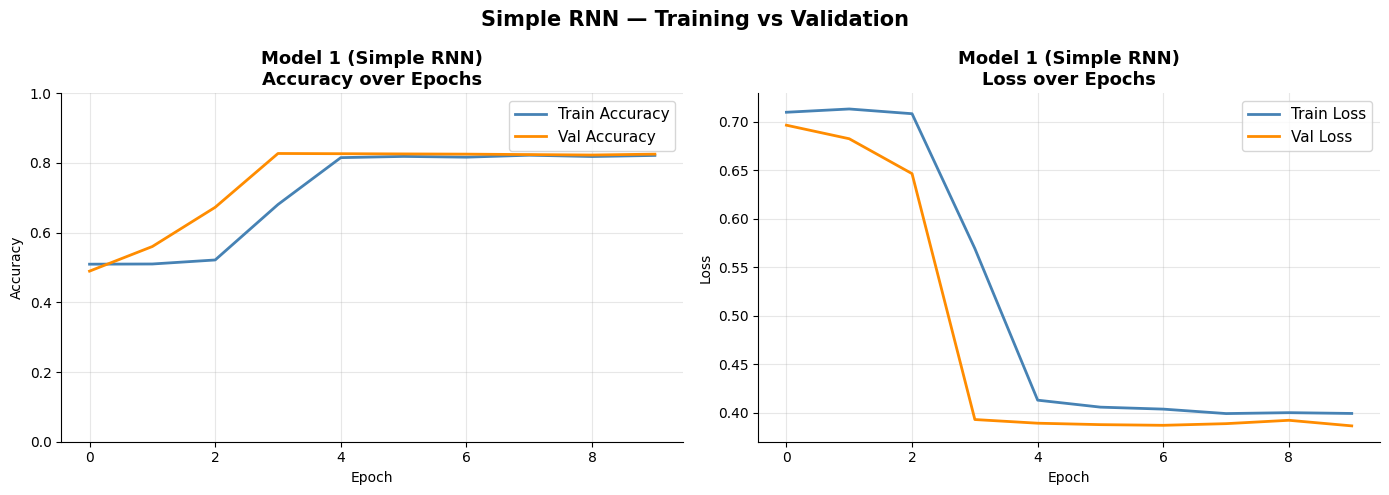

Model 1 training curves plotted!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Plot ──────────────────────────────────────────────────
axes[0].plot(history1.history['accuracy'],
             label='Train Accuracy',
             color='steelblue',
             linewidth=2)

axes[0].plot(history1.history['val_accuracy'],
             label='Val Accuracy',
             color='darkorange',
             linewidth=2,
             )

axes[0].set_title('Model 1 (Simple RNN)\nAccuracy over Epochs',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim([0, 1])

# ── Loss Plot ──────────────────────────────────────────────────────
axes[1].plot(history1.history['loss'],
             label='Train Loss',
             color='steelblue',
             linewidth=2)

axes[1].plot(history1.history['val_loss'],
             label='Val Loss',
             color='darkorange',
             linewidth=2,)

axes[1].set_title('Model 1 (Simple RNN)\nLoss over Epochs',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Simple RNN — Training vs Validation',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('model1_rnn_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Model 1 training curves plotted!")

Plot Model 1 Confusion Matrix and Store Results

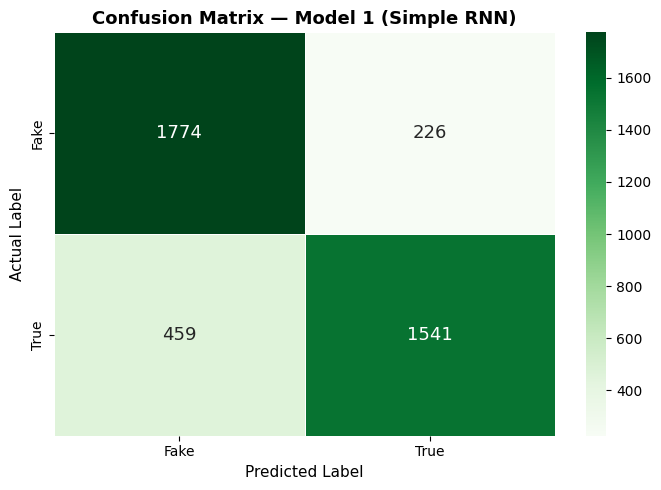


Model 1 results stored.


In [ ]:
cm1 = confusion_matrix(y_test, y_pred1)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'],
            linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Model 1 (Simple RNN)', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('model1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

results = {}
results['Model 1 — Simple RNN'] = {
    'accuracy': acc1, 'history': history1,
    'y_pred': y_pred1, 'y_pred_prob': y_pred1_prob, 'cm': cm1
}

print(f"\nModel 1 results stored.")
print("=" * 55)

Model 1 Error Analysis: Misclassified Examples

In [ ]:
print("=" * 55)
print("   MODEL 1 — ERROR ANALYSIS")
print("=" * 55)

label_names        = {0: 'FAKE NEWS', 1: 'TRUE NEWS'}
misclassified_idx1 = np.where(y_pred1 != y_test)[0]

print(f"\nTotal misclassified : {len(misclassified_idx1)}")
print(f"Total test samples  : {len(y_test)}")
print(f"Error rate          : {len(misclassified_idx1)/len(y_test)*100:.2f}%")

print("\n--- 3 Misclassified Examples ---")
for i, idx in enumerate(misclassified_idx1[:3]):
    print(f"\n[{i+1}]")
    print(f"   Text snippet  : {X_test[idx][:150]}...")
    print(f"   Actual label  : {label_names[y_test[idx]]}")
    print(f"   Predicted     : {label_names[y_pred1[idx]]}  <- WRONG")
    print(f"   Confidence    : {y_pred1_prob[idx][0]:.4f}")


   MODEL 1 — ERROR ANALYSIS

Total misclassified : 685
Total test samples  : 4000
Error rate          : 17.12%

--- 3 Misclassified Examples ---

[1]
   Text snippet  : offering american sht sandwich health care coverage plan slammed conservative group doctor hospital democrat liberal trumpcare republican attempt repe...
   Actual label  : FAKE NEWS
   Predicted     : TRUE NEWS  <- WRONG
   Confidence    : 0.8553

[2]
   Text snippet  : brock allen turner yearold former student stanford university sentenced six month jail raping unconscious woman campus january prosecutor case recomme...
   Actual label  : FAKE NEWS
   Predicted     : TRUE NEWS  <- WRONG
   Confidence    : 0.8553

[3]
   Text snippet  : reuters yous senate monday confirmed william emanuel veteran managementside labor lawyer national labor relation board giving agency republican majori...
   Actual label  : TRUE NEWS
   Predicted     : FAKE NEWS  <- WRONG
   Confidence    : 0.4309


##**Build Model 2: LSTM Architecture**

In [ ]:

model2 = Sequential(name='Model2_LSTM')

# Embedding: same settings as Model 1 for fair comparison
model2.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    name='embedding_lstm'
))

# LSTM: memory gates handle long-range dependencies
# dropout regularises input; recurrent_dropout regularises hidden state
model2.add(LSTM(
    units=64,
    activation='tanh',
    recurrent_activation='sigmoid',
    dropout=0.2,
    recurrent_dropout=0.2,
    name='lstm_layer'
))

model2.add(Dropout(0.3, name='dropout_lstm'))

model2.add(Dense(1, activation='sigmoid', name='output_lstm'))

model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_lstm (Dropout)          │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_lstm (Dense)             │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Set Up Early Stopping for Model 2

In [ ]:
early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)


 Train Model 2 (LSTM)

In [ ]:
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

print("\nModel 2 training complete!")

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 204s 884ms/step - accuracy: 0.5303 - loss: 0.6829 - val_accuracy: 0.5369 - val_loss: 0.6721
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 197s 874ms/step - accuracy: 0.5365 - loss: 0.6702 - val_accuracy: 0.5312 - val_loss: 0.6706
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 199s 887ms/step - accuracy: 0.5431 - loss: 0.6646 - val_accuracy: 0.5325 - val_loss: 0.6706
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 202s 885ms/step - accuracy: 0.5479 - loss: 0.6622 - val_accuracy: 0.5375 - val_loss: 0.6709
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 204s 907ms/step - accuracy: 0.6286 - loss: 0.6087 - val_accuracy: 0.8956 - val_loss: 0.3557
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 195s 866ms/step - accuracy: 0.9575 - loss: 0.1644 - val_accuracy: 0.9894 - val_loss: 0.0557
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 192s 853ms/step - accuracy: 0.9737 - loss: 0.1072 - val_accuracy: 0.9881 - val_loss: 0.0534
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 206s 872ms/step - accuracy: 0.9787 -

Evaluate Model 2: Accuracy and Classification Report

In [ ]:
print("=" * 55)
print("   MODEL 2 — LSTM EVALUATION")
print("=" * 55)

y_pred2_prob = model2.predict(X_test_pad, verbose=0)
y_pred2      = (y_pred2_prob > 0.5).astype(int).flatten()

acc2 = accuracy_score(y_test, y_pred2)
print(f"\nTest Accuracy : {acc2:.4f}  ({acc2*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=['Fake News (0)', 'True News (1)']))



   MODEL 2 — LSTM EVALUATION

Test Accuracy : 0.9755  (97.55%)

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.97      0.98      0.98      2000
True News (1)       0.98      0.97      0.98      2000

     accuracy                           0.98      4000
    macro avg       0.98      0.98      0.98      4000
 weighted avg       0.98      0.98      0.98      4000



Plot Model 2 Training Accuracy and Loss Curves

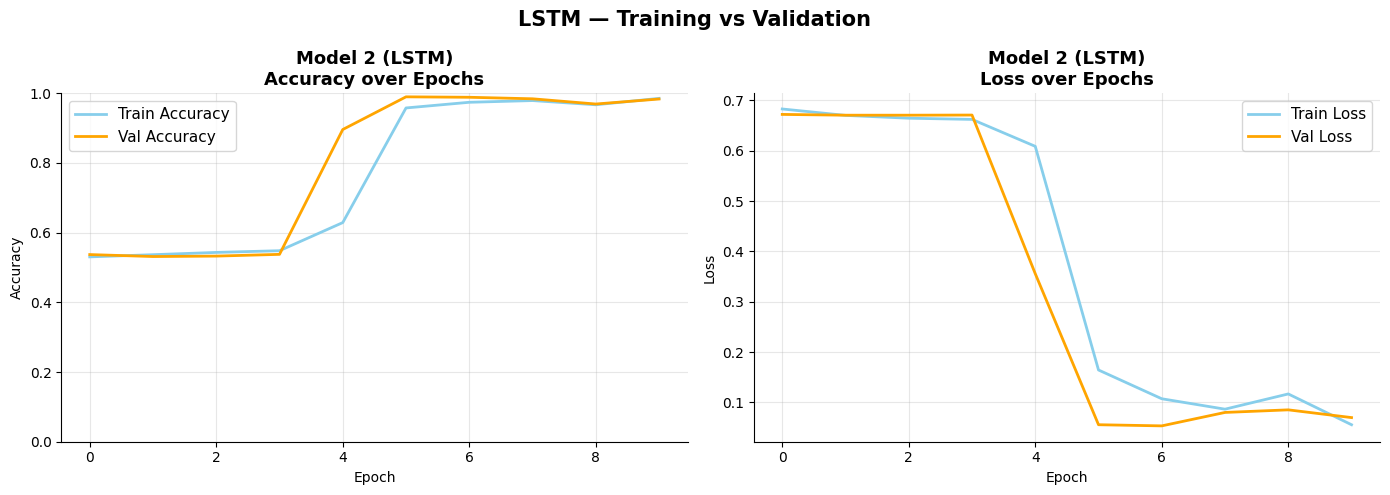

Model 2 training curves plotted!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Plot ──────────────────────────────────────────────────
axes[0].plot(history2.history['accuracy'],
             label='Train Accuracy',
             color='steelblue',
             linewidth=2)

axes[0].plot(history2.history['val_accuracy'],
             label='Val Accuracy',
             color='darkorange',
             linewidth=2,
             )

axes[0].set_title('Model 2 (LSTM)\nAccuracy over Epochs',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim([0, 1])

# ── Loss Plot ──────────────────────────────────────────────────────
axes[1].plot(history2.history['loss'],
             label='Train Loss',
             color='steelblue',
             linewidth=2)

axes[1].plot(history2.history['val_loss'],
             label='Val Loss',
             color='darkorange',
             linewidth=2,
             )

axes[1].set_title('Model 2 (LSTM)\nLoss over Epochs',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('LSTM — Training vs Validation',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('model2_lstm_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Model 2 training curves plotted!")

Plot Model 2 Confusion Matrix

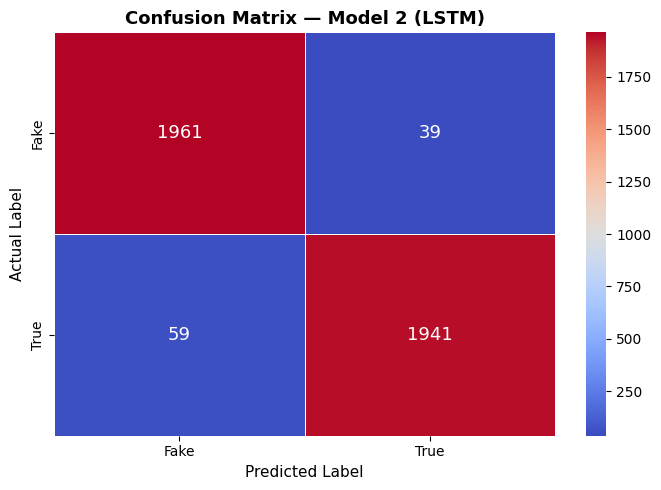

In [ ]:

cm2 = confusion_matrix(y_test, y_pred2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'],
            linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Model 2 (LSTM)', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



Store Model 2 Results

In [ ]:
if 'results' not in globals():
    results = {}

results['Model 2 — LSTM'] = {
    'accuracy': acc2, 'history': history2,
    'y_pred': y_pred2, 'y_pred_prob': y_pred2_prob, 'cm': cm2
}

Model 2 Error Analysis: Misclassified Examples

In [ ]:
print("=" * 55)
print("   MODEL 2 — ERROR ANALYSIS")
print("=" * 55)

misclassified_idx2 = np.where(y_pred2 != y_test)[0]

print(f"\nTotal misclassified : {len(misclassified_idx2)}")
print(f"Total test samples  : {len(y_test)}")
print(f"Error rate          : {len(misclassified_idx2)/len(y_test)*100:.2f}%")

print("\n--- 3 Misclassified Examples ---")
for i, idx in enumerate(misclassified_idx2[:3]):
    print(f"\n[{i+1}]")
    print(f"   Text snippet  : {X_test[idx][:150]}...")
    print(f"   Actual label  : {label_names[y_test[idx]]}")
    print(f"   Predicted     : {label_names[y_pred2[idx]]}  <- WRONG")
    print(f"   Confidence    : {y_pred2_prob[idx][0]:.4f}")


   MODEL 2 — ERROR ANALYSIS

Total misclassified : 98
Total test samples  : 4000
Error rate          : 2.45%

--- 3 Misclassified Examples ---

[1]
   Text snippet  : johannesburg reuters donald trump interested rigged election zimbabwean opposition leader tendai biti say could teach thing two biti arrested treason ...
   Actual label  : TRUE NEWS
   Predicted     : FAKE NEWS  <- WRONG
   Confidence    : 0.0825

[2]
   Text snippet  : picture snapped white house photographer traveling president left golf course sterling went viral almost immediately news outlet picked story appeared...
   Actual label  : FAKE NEWS
   Predicted     : TRUE NEWS  <- WRONG
   Confidence    : 0.9870

[3]
   Text snippet  : stock market lost point abc news erroneously reported general flynn communication russian ambassador sergey kislyak trump campaign turn stock market p...
   Actual label  : FAKE NEWS
   Predicted     : TRUE NEWS  <- WRONG
   Confidence    : 0.9843


Compare Model 1 vs Model 2 Accuracy Improvement

In [ ]:
print(f"\nImprovement over Simple RNN:")
print(f"   Model 1 RNN  Accuracy : {acc1*100:.2f}%")
print(f"   Model 2 LSTM Accuracy : {acc2*100:.2f}%")
print(f"   Gain                  : +{(acc2 - acc1)*100:.2f}%")
print("=" * 55)


Improvement over Simple RNN:
   Model 1 RNN  Accuracy : 82.88%
   Model 2 LSTM Accuracy : 97.55%
   Gain                  : +14.68%


 Plot Model 1 vs Model 2 Validation Accuracy and Loss (Overlay

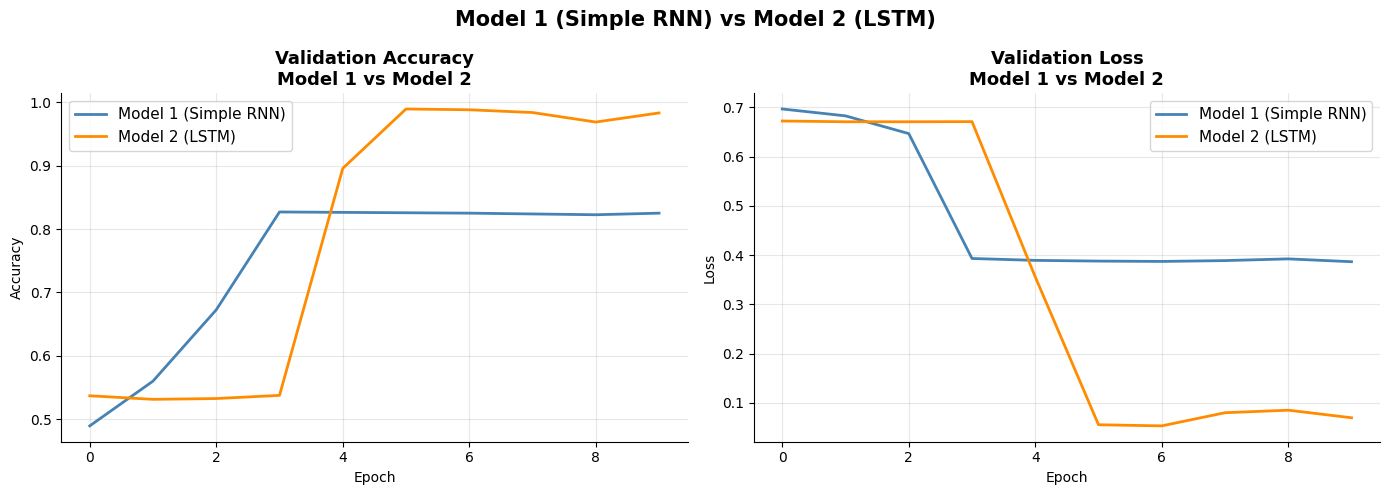

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Validation Accuracy ────────────────────────────────────────────
axes[0].plot(history1.history['val_accuracy'],
             label='Model 1 (Simple RNN)',
             color='steelblue',
             linewidth=2)

axes[0].plot(history2.history['val_accuracy'],
             label='Model 2 (LSTM)',
             color='darkorange',
             linewidth=2)

axes[0].set_title('Validation Accuracy\nModel 1 vs Model 2',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Validation Loss ────────────────────────────────────────────────
axes[1].plot(history1.history['val_loss'],
             label='Model 1 (Simple RNN)',
             color='steelblue',
             linewidth=2)

axes[1].plot(history2.history['val_loss'],
             label='Model 2 (LSTM)',
             color='darkorange',
             linewidth=2)

axes[1].set_title('Validation Loss\nModel 1 vs Model 2',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model 1 (Simple RNN) vs Model 2 (LSTM)',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('model1_vs_model2.png', dpi=150, bbox_inches='tight')
plt.show()

Plot Model 1 vs Model 2 Accuracy Bar Chart

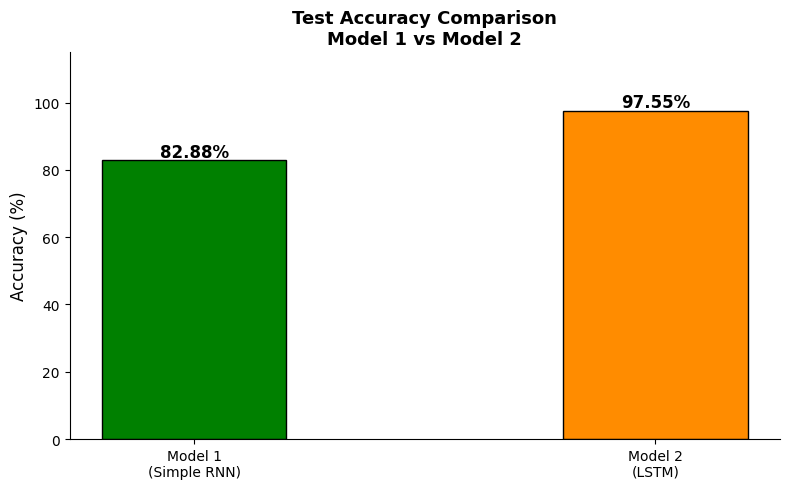

   MODEL 1 vs MODEL 2 SUMMARY
   Model 1 (Simple RNN) : 82.88%
   Model 2 (LSTM)       : 97.55%
   Winner               : Model 2 LSTM


In [ ]:


# ── Accuracy Comparison Bar Chart ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Model 1\n(Simple RNN)', 'Model 2\n(LSTM)']
accs   = [acc1 * 100, acc2 * 100]
colors = ['Green', 'darkorange']

bars = ax.bar(models, accs,
              color=colors,
              edgecolor='black',
              width=0.4)

ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=12)

ax.set_title('Test Accuracy Comparison\nModel 1 vs Model 2',
             fontsize=13, fontweight='bold')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{acc:.2f}%',
            ha='center',
            fontsize=12,
            fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model1_vs_model2_accuracy.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

print("=" * 55)
print("   MODEL 1 vs MODEL 2 SUMMARY")
print("=" * 55)
print(f"   Model 1 (Simple RNN) : {acc1*100:.2f}%")
print(f"   Model 2 (LSTM)       : {acc2*100:.2f}%")
print(f"   Winner               : {'Model 2 LSTM' if acc2 > acc1 else 'Model 1 RNN'}")
print("=" * 55)

 Download Pretrained GloVe Word2Vec Embeddings

In [ ]:
# GloVe trained on Wikipedia + Gigaword (~6B tokens)
# 400K vocabulary, 100-dimensional vectors, ~128MB download

print("Downloading pretrained GloVe embeddings...")
print("   Model : glove-wiki-gigaword-100 (100-dimensional)")
print("   Size  : ~128MB — this may take 2-4 minutes")
print("-" * 55)

embedding_model = api.load('glove-wiki-gigaword-100')

print(f"\nGloVe embeddings loaded!")
print(f"   Vocabulary size : {len(embedding_model):,} words")
print(f"   Embedding dims  : {embedding_model.vector_size}")
print(f"\nSample — similar words to 'news':")
print([w for w, _ in embedding_model.most_similar('news', topn=5)])

   Model : glove-wiki-gigaword-100 (100-dimensional)
   Size  : ~128MB — this may take 2-4 minutes
-------------------------------------------------------
[==================================================] 100.0% 128.1/128.1MB downloaded

GloVe embeddings loaded!
   Vocabulary size : 400,000 words
   Embedding dims  : 100

Sample — similar words to 'news':
['press', 'newspaper', 'media', 'interview', 'reported']


Build the GloVe Embedding Matrix

In [ ]:
EMBEDDING_DIM_W2V = 100   # must match glove-wiki-gigaword-100

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))

found     = 0
not_found = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / min(VOCAB_SIZE, len(word_index)) * 100

print("=" * 55)
print("   EMBEDDING MATRIX SUMMARY")
print("=" * 55)
print(f"   Matrix shape     : {embedding_matrix.shape}")
print(f"   Words in GloVe   : {found:,}")
print(f"   Words NOT found  : {not_found:,}")
print(f"   Coverage         : {coverage:.1f}%")
print("=" * 55)
print("Note: higher coverage = better pretrained knowledge transfer")

   EMBEDDING MATRIX SUMMARY
   Matrix shape     : (20000, 100)
   Words in GloVe   : 18,310
   Words NOT found  : 1,689
   Coverage         : 91.5%
Note: higher coverage = better pretrained knowledge transfer


##**Build Model 3: LSTM with Frozen GloVe Embeddings**

In [ ]:
# ============================================================
# MODEL 3 — LSTM with Pretrained Word2Vec (GloVe) Embedding


model3 = Sequential(name='Model3_LSTM_GloVe')

# Embedding loaded with pretrained GloVe weights, then frozen
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM_W2V,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False,               # FROZEN — key difference from Model 2
    name='embedding_glove_frozen'
))

# LSTM — same architecture as Model 2 for fair comparison
model3.add(LSTM(
    units=64,
    activation='tanh',
    recurrent_activation='sigmoid',
    dropout=0.2,
    recurrent_dropout=0.2,
    name='lstm_glove'
))

model3.add(Dropout(0.4, name='dropout_glove'))

model3.add(Dense(1, activation='sigmoid', name='output_glove'))

model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model3.summary()



Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove_frozen          │ ?                      │     2,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_glove (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_glove (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_glove (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Set Up Early Stopping for Model 3

In [ ]:
early_stop3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

Train Model 3 (LSTM + GloVe Word2Vec)


In [ ]:
print("Training Model 3 (LSTM + GloVe Word2Vec)...")
print("-" * 60)

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop3],
    verbose=1
)

print("\nModel 3 training complete!")

Training Model 3 (LSTM + GloVe Word2Vec)...
------------------------------------------------------------
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 190s 844ms/step - accuracy: 0.9469 - loss: 0.1842 - val_accuracy: 0.9650 - val_loss: 0.1946
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9587 - loss: 0.1664 - val_accuracy: 0.9694 - val_loss: 0.1147
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9362 - loss: 0.2158 - val_accuracy: 0.9112 - val_loss: 0.2527
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 171s 762ms/step - accuracy: 0.9397 - loss: 0.2020 - val_accuracy: 0.9606 - val_loss: 0.1608
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 198s 743ms/step - accuracy: 0.9523 - loss: 0.1748 - val_accuracy: 0.9550 - val_loss: 0.1633
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Model 3 training complete!


Evaluate Model 3: Accuracy and Classification Report

In [ ]:
print("=" * 60)
print("   MODEL 3 — LSTM + WORD2VEC EVALUATION")
print("=" * 60)

y_pred3_prob = model3.predict(X_test_pad, verbose=0)
y_pred3      = (y_pred3_prob > 0.5).astype(int).flatten()

acc3 = accuracy_score(y_test, y_pred3)
print(f"\nTest Accuracy : {acc3:.4f}  ({acc3*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred3, target_names=['Fake News (0)', 'True News (1)']))



   MODEL 3 — LSTM + WORD2VEC EVALUATION

Test Accuracy : 0.9643  (96.43%)

Classification Report:
               precision    recall  f1-score   support

Fake News (0)       0.97      0.96      0.96      2000
True News (1)       0.96      0.97      0.96      2000

     accuracy                           0.96      4000
    macro avg       0.96      0.96      0.96      4000
 weighted avg       0.96      0.96      0.96      4000



Plot Model 3 Confusion Matrix

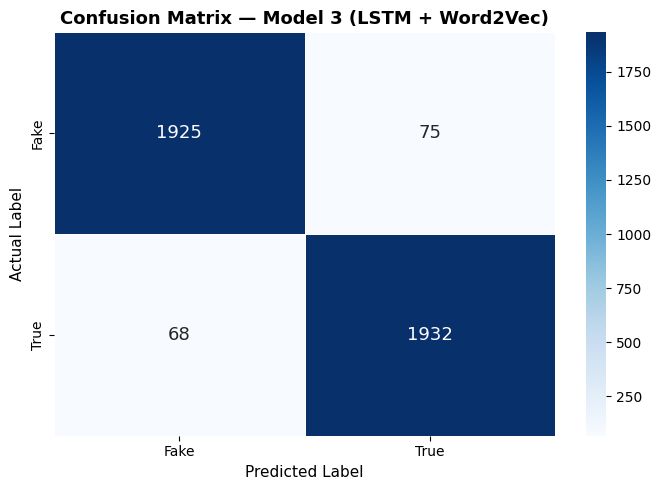

In [ ]:
cm3 = confusion_matrix(y_test, y_pred3)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'],
            linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Model 3 (LSTM + Word2Vec)', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('model3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Store Model 3 Results and Print All Model Accuracies

In [ ]:
results['Model 3 — LSTM + Word2Vec'] = {
    'accuracy': acc3, 'history': history3,
    'y_pred': y_pred3, 'y_pred_prob': y_pred3_prob, 'cm': cm3
}

print(f"\nAll models so far:")
for name, res in results.items():
    print(f"   {name:<30} -> {res['accuracy']*100:.2f}%")
print("=" * 60)


All models so far:
   Model 1 — Simple RNN           -> 82.88%
   Model 3 — LSTM + Word2Vec      -> 96.43%


Model 3 Error Analysis: Misclassified Examples

In [ ]:
print("=" * 60)
print("   MODEL 3 — ERROR ANALYSIS")
print("=" * 60)

misclassified_idx3 = np.where(y_pred3 != y_test)[0]

print(f"\nTotal misclassified : {len(misclassified_idx3)}")
print(f"Total test samples  : {len(y_test)}")
print(f"Error rate          : {len(misclassified_idx3)/len(y_test)*100:.2f}%")

print("\n--- 3 Misclassified Examples ---")
for i, idx in enumerate(misclassified_idx3[:3]):
    print(f"\n[{i+1}]")
    print(f"   Text snippet  : {X_test[idx][:150]}...")
    print(f"   Actual label  : {label_names[y_test[idx]]}")
    print(f"   Predicted     : {label_names[y_pred3[idx]]}  <- WRONG")
    print(f"   Confidence    : {y_pred3_prob[idx][0]:.4f}")


   MODEL 3 — ERROR ANALYSIS

Total misclassified : 143
Total test samples  : 4000
Error rate          : 3.57%

--- 3 Misclassified Examples ---

[1]
   Text snippet  : washington reuters yous treasury secretary steven mnuchin said sunday not regret using government plane travel kentucky august wife view solar eclipse...
   Actual label  : TRUE NEWS
   Predicted     : FAKE NEWS  <- WRONG
   Confidence    : 0.0097

[2]
   Text snippet  : picture snapped white house photographer traveling president left golf course sterling went viral almost immediately news outlet picked story appeared...
   Actual label  : FAKE NEWS
   Predicted     : TRUE NEWS  <- WRONG
   Confidence    : 0.9718

[3]
   Text snippet  : beijing reuters yous president donald trump left beijing friday asiapacific economic cooperation summit vietnam first lady melania stayed behind play ...
   Actual label  : TRUE NEWS
   Predicted     : FAKE NEWS  <- WRONG
   Confidence    : 0.1167


Plot All 3 Models Validation Curves Overlay

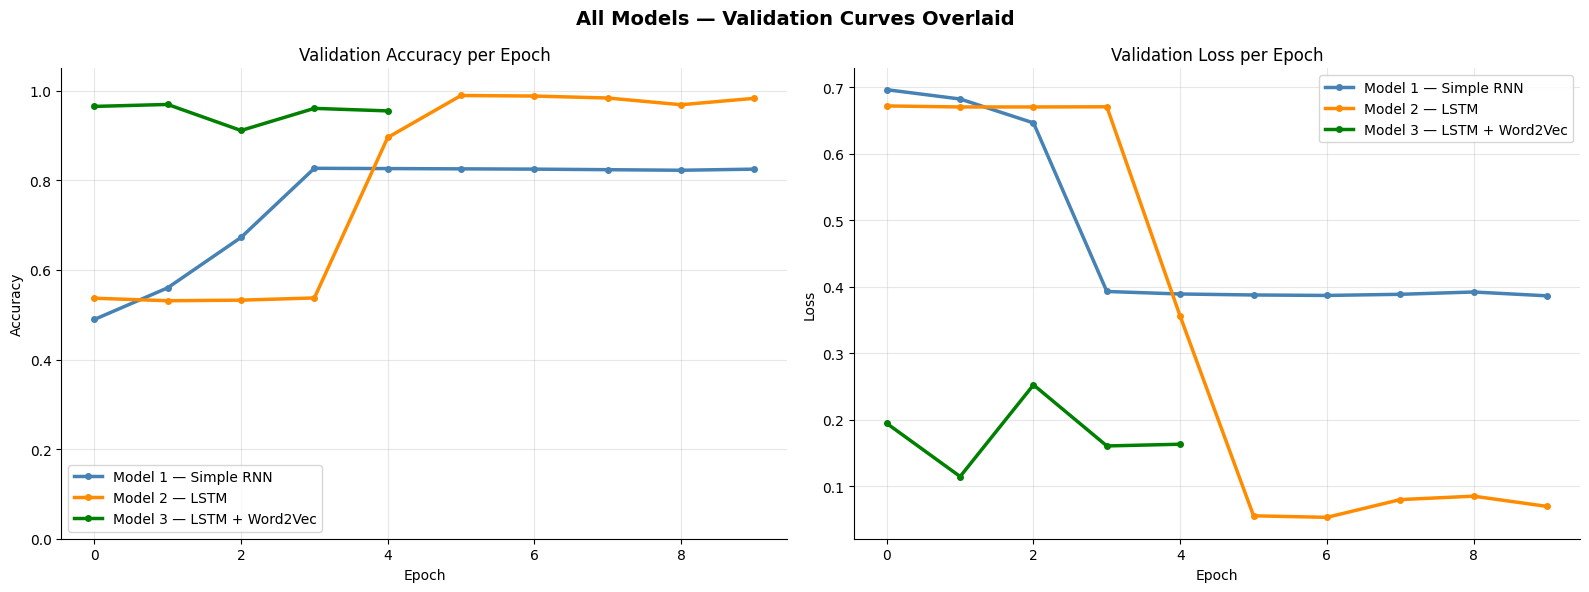

All-models overlay chart saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models — Validation Curves Overlaid', fontsize=14, fontweight='bold')

model_data = [
    ('Model 1 — Simple RNN',      history1, 'steelblue'),
    ('Model 2 — LSTM',            history2, 'darkorange'),
    ('Model 3 — LSTM + Word2Vec', history3, 'green'),
]

for name, hist, color in model_data:
    axes[0].plot(hist.history['val_accuracy'], color=color, linewidth=2.5, marker='o', markersize=4, label=name)
    axes[1].plot(hist.history['val_loss'],     color=color, linewidth=2.5, marker='o', markersize=4, label=name)

axes[0].set_title('Validation Accuracy per Epoch', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].set_title('Validation Loss per Epoch', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('all_models_training_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("All-models overlay chart saved!")

Plot All 3 Confusion Matrices Side by Side

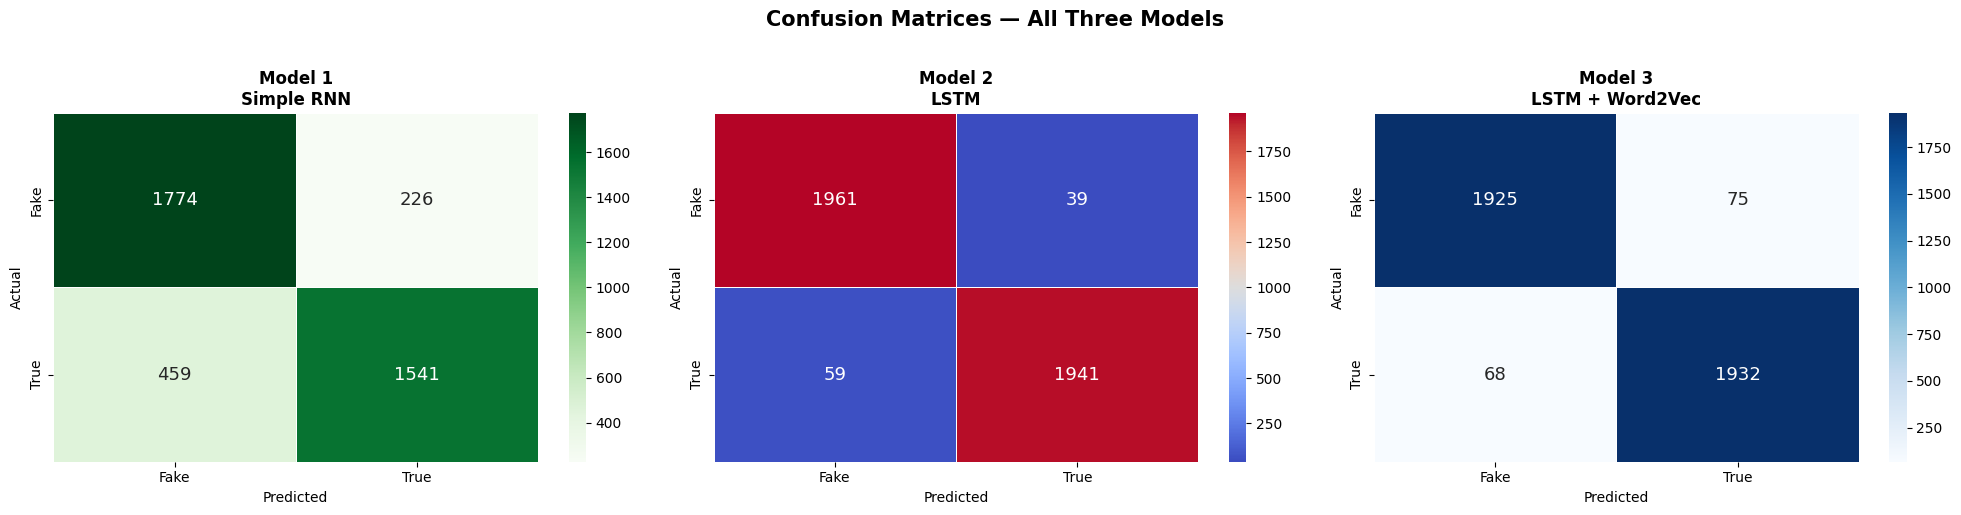

Combined confusion matrices saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Three Models', fontsize=15, fontweight='bold', y=1.02)

cms    = [cm1,              cm2,         cm3]
titles = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + Word2Vec']
cmaps  = ['Greens',          'coolwarm',   'Blues']

for ax, cm, title, cmap in zip(axes, cms, titles, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Fake', 'True'],
                yticklabels=['Fake', 'True'],
                linewidths=0.5, ax=ax, annot_kws={'size': 13})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Combined confusion matrices saved!")

Full Model Comparison Table and Final Accuracy Bar Chart

                        FULL MODEL COMPARISON TABLE                        
Model                            Accuracy  Precision     Recall   F1-Score
---------------------------------------------------------------------------
Model 1 — Simple RNN               82.88%     87.21%     77.05%     81.82%
Model 2 — LSTM                     97.55%     98.03%     97.05%     97.54%
Model 3 — LSTM + Word2Vec          96.43%     96.26%     96.60%     96.43%


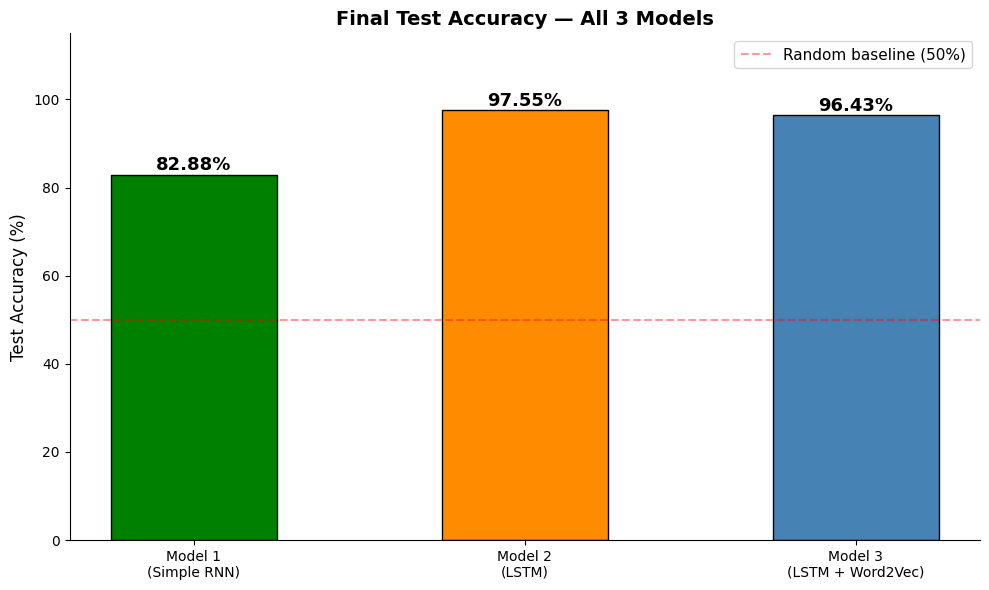

   FINAL MODEL COMPARISON SUMMARY
   Model 1 — Simple RNN               82.88%
   Model 2 — LSTM                     97.55%
   Model 3 — LSTM + Word2Vec          96.43%

   Best Model : Model 2 — LSTM  (97.55%)


In [ ]:
model_keys = [
    'Model 1 — Simple RNN',
    'Model 2 — LSTM',
    'Model 3 — LSTM + Word2Vec'
]

# Ensure Model 2 results are in the dictionary (in case previous cell was skipped)
if 'Model 2 — LSTM' not in results:
    results['Model 2 — LSTM'] = {
        'accuracy': acc2, 'history': history2,
        'y_pred': y_pred2, 'y_pred_prob': y_pred2_prob, 'cm': cm2
    }

print("=" * 75)
print(f"{'FULL MODEL COMPARISON TABLE':^75}")
print("=" * 75)
print(f"{'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 75)

comparison_data = []
for key in model_keys:
    y_pred = results[key]['y_pred']
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    comparison_data.append({'Model': key, 'Accuracy': acc,
                            'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"{key:<30} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>9.2f}% {f1*100:>9.2f}%")

print("=" * 75)

accs   = [results[k]['accuracy'] * 100 for k in model_keys]
colors = ['green', 'darkorange', 'steelblue']
labels = ['Model 1\n(Simple RNN)', 'Model 2\n(LSTM)', 'Model 3\n(LSTM + Word2Vec)']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Test Accuracy — All 3 Models', fontsize=14, fontweight='bold')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.4, label='Random baseline (50%)')
ax.legend(fontsize=11)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('final_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_idx = int(np.argmax(accs))
print("=" * 55)
print("   FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
for key, acc in zip(model_keys, accs):
    print(f"   {key:<30} {acc:>9.2f}%")
print(f"\n   Best Model : {model_keys[best_idx]}  ({accs[best_idx]:.2f}%)")
print("=" * 55)

Build and Launch the Gradio Interactive Demo App

In [ ]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences


def predict_news(text):
    """
    Takes raw input text and returns prediction with confidence.
    """

    cleaned = clean_text(text)

    if cleaned.strip() == '':
        return "Please enter valid text"

    # Tokenize
    seq = tokenizer.texts_to_sequences([cleaned])

    # Pad
    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    # Predictions
    prob1 = model1.predict(padded, verbose=0)[0][0]
    prob2 = model2.predict(padded, verbose=0)[0][0]
    prob3 = model3.predict(padded, verbose=0)[0][0]

    pred1 = int(prob1 > 0.5)
    pred2 = int(prob2 > 0.5)
    pred3 = int(prob3 > 0.5)

    label_map = {0: 'FAKE NEWS', 1: 'TRUE NEWS'}

    result = f"""
======================================
FAKE NEWS DETECTION RESULT
======================================

INPUT TEXT:
{text}

--------------------------------------
MODEL 1 (Simple RNN)
Prediction: {label_map[pred1]}
Confidence: {max(prob1, 1-prob1)*100:.2f}%

MODEL 2 (LSTM)
Prediction: {label_map[pred2]}
Confidence: {max(prob2, 1-prob2)*100:.2f}%

MODEL 3 (LSTM + Word2Vec - BEST)
Prediction: {label_map[pred3]}
Confidence: {max(prob3, 1-prob3)*100:.2f}%

======================================
FINAL VERDICT: {label_map[pred3]}
======================================
"""
    return result


# WORLDWIDE TRUE / FAKE NEWS EXAMPLES (UPDATED)

examples = [

    # TRUE NEWS
    ["The World Health Organization reported a global reduction in malaria cases due to improved healthcare systems and prevention programs in Africa and Asia."],

    ["The Federal Reserve announced that interest rates will remain unchanged as inflation shows signs of stabilization in the United States."],

    ["The United Nations held a climate summit to discuss global strategies for reducing carbon emissions and supporting renewable energy."],

    ["The European Space Agency successfully launched a satellite to monitor environmental changes and climate patterns on Earth."],

    ["The UK government introduced a new climate policy aimed at reducing carbon emissions by 40 percent before 2035."],


    # FAKE NEWS
    ["A viral online post claims that drinking lemon water cures all diseases instantly, but there is no scientific evidence to support this."],

    ["Social media rumors say NASA discovered a hidden underwater alien civilization in the Atlantic Ocean, but this has been denied by scientists."],

    ["A false claim suggests the United Nations will ban internet access globally within one year, which is not true."],

    ["Online posts claim humans will develop superpowers after 2026 due to cosmic energy changes, but experts reject this claim."],

    ["Fake reports suggest governments are controlling weather using satellites, but no scientific proof exists."]
]


# GRADIO INTERFACE
interface = gr.Interface(
    fn=predict_news,

    inputs=gr.Textbox(
        lines=6,
        placeholder="Paste news article, tweet, or headline...",
        label="Enter News Text"
    ),

    outputs=gr.Textbox(
        lines=22,
        label="Prediction Result"
    ),

    title="Fake News Detector (Deep Learning AI)",

    description="""
AI-based system that classifies news as TRUE or FAKE using 3 deep learning models:

- Simple RNN
- LSTM
- LSTM + Word2Vec (Best Model)

Paste any news article below to get instant prediction.
""",

    examples=examples,
    theme=gr.themes.Soft(),
    allow_flagging="never"
)


interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://661863fcc04a2ff2d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
